# 리워드 모델링 (Reward Modeling)

리워드 모델은 여러 응답 중 **사람이 더 선호할 만한 응답에 높은 점수**를 주도록 학습하는 모델이다. RLHF에서는 정책 모델을 바로 강화학습시키기 전에, 보통 `chosen`과 `rejected` 응답 쌍을 이용해 이런 선호 점수 함수를 먼저 학습한다.


<a id="objectives"></a>
# 학습 목표

이 실습에서 확인할 내용은 다음과 같다.

- 리워드 모델링의 기본 개념을 이해한다.
- `prompt`, `chosen`, `rejected` 형태의 preference 데이터셋을 전처리한다.
- GPT-2 시퀀스 분류 모델을 스칼라 reward 모델로 사용한다.
- LoRA를 적용해 적은 수의 파라미터만 학습한다.
- `RewardTrainer`로 pairwise preference 학습을 수행한다.
- 두 응답의 reward score를 비교해 모델의 선호 정확도를 확인한다.


<a id="setup"></a>
# 환경 설정

## 라이브러리 설치


In [1]:
%%time

!pip uninstall -y torchao -q

%pip install -q -U \
  "trl==1.9.0" \
  "transformers==5.14.1" \
  "peft==0.19.1" \
  "datasets==5.0.0" \
  "accelerate==1.14.0"

%pip install -q -U nltk rouge_score matplotlib rich

import torch, trl, transformers, peft, datasets

print("PyTorch:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

print("trl:", trl.__version__)
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
print("datasets:", datasets.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 885.0/885.0 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 kB 31.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyiceberg 0.11.1 requires rich<15.0.0,>=10.11.0, but you have rich 15.0.0 which is incompatible.
bigframes 2.42.0 requires rich<14,>=12.4.4, but y

## 라이브러리 임포트

In [2]:
import json
import warnings

import matplotlib.pyplot as plt
import torch
from datasets import DatasetDict, load_dataset
from peft import LoraConfig, TaskType
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from trl import RewardConfig, RewardTrainer

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)


사용 디바이스: cuda


## 헬퍼 함수 정의

In [3]:
def save_to_json(data, file_path):
    """딕셔너리를 JSON 파일로 저장한다."""
    with open(file_path, "w", encoding="utf-8") as json_file:
        json.dump(data, json_file, indent=4, ensure_ascii=False)
    print(f"저장 완료: {file_path}")


def load_from_json(file_path):
    """JSON 파일을 불러온다."""
    with open(file_path, "r", encoding="utf-8") as json_file:
        return json.load(json_file)


<a id="dataset"></a>
## 데이터셋

이 섹션에서는 리워드 모델 학습에 사용할 데이터셋을 불러온다. 여기서는 Hugging Face의 **Dahoas/synthetic-instruct-gptj-pairwise** 데이터셋을 사용한다. 이는 지시-따르기(instruction-following) 모델의 학습·평가를 위해 설계된 합성 데이터셋으로, 프롬프트와 응답 쌍을 포함하며 한 응답이 다른 응답보다 선호(preferred)된다. 주된 용도는 더 나은 응답과 더 나쁜 응답을 구분하도록 모델을 학습시키는 것으로, RLHF(인간 피드백 기반 강화학습) 같은 작업에 필수적이다.

### 용도
좋은 응답과 나쁜 응답 쌍으로부터 학습하여, 모델이 지시를 더 잘 이해하고 따르도록 돕는다.

### 활용 분야
- **강화학습:** 피드백에 기반해 더 나은 응답을 선호하도록 모델 개선
- **언어 모델 미세조정:** 지시-따르기 작업 성능 향상
- **평가:** 고품질/저품질 응답을 구분하는 능력 측정

In [4]:
# Dahoas/synthetic-instruct-gptj-pairwise 데이터셋 불러오기
dataset = load_dataset("Dahoas/synthetic-instruct-gptj-pairwise")
# 데이터셋 확인
print(dataset)

dataset_infos.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

data/train-00000-of-00001-1e5d57b93c448e(…): reconstructing file:   0%|          |  0.00B / 18.2MB            

data/train-00000-of-00001-1e5d57b93c448e(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/33143 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['prompt', 'chosen', 'rejected'],
        num_rows: 33143
    })
})


### 데이터셋 특징

데이터셋을 더 잘 이해하기 위해 몇 개 샘플을 살펴본다. 학습 세트의 첫 10개 예시에 대해 `prompt`, `chosen`, `rejected`를 출력한다.

- `Prompt`: 모델이 응답해야 할 텍스트 프롬프트
- `Chosen`: 프롬프트에 대한 **선호되는** 응답
- `Rejected`: 덜 선호되는 응답

In [5]:
for i in range(10):
    print("프롬프트")
    print(dataset["train"][i]["prompt"], "\n")

    print("선호 응답")
    print(dataset["train"][i]["chosen"], "\n")

    print("비선호 응답")
    print(dataset["train"][i]["rejected"], "\n")
    print("---------------------------\n")

프롬프트
I was wondering if you could walk me through the process of setting up a hydroponic garden for herbs. 

선호 응답
Sure! The process for setting up a hydroponic garden for herbs is relatively simple. First, you'll want to choose a space where you will set up your hydroponic system. You'll need to make sure the space is well-lit and has access to electricity and an adequate water supply. Next, you'll need to choose the type of hydroponic system you want to use. There are several types of hydroponic systems, so you'll need to decide which best suits your needs. Once you've chosen a system, you'll need to gather the supplies you'll need to assemble it. This includes things like pumps, growing trays, grow lights, and nutrients. Once you've assembled the system, you'll need to add your choice of herbs to the system. Lastly, you'll need to monitor and adjust the system as needed to ensure your herbs are getting the correct amount of light, water, and nutrients. 

비선호 응답
How do I store a bage

<a id="model-and-tokenizer-setup"></a>
## 모델과 토크나이저 설정

이 섹션에서는 학습에 사용할 토크나이저와 모델을 설정한다. 응답의 품질을 판단하기 위해 **시퀀스 분류(sequence classification)용 GPT-2** 모델을 사용한다.

모델 이름은 `"gpt2"`로 지정한다. `GPT2Tokenizer.from_pretrained`와 `GPT2ForSequenceClassification.from_pretrained`로 토크나이저·모델을 초기화하며, 점수(순위) 값을 위해 `num_labels=1`로 설정한다. 패딩 처리를 위해 토크나이저의 `pad_token`을 `eos_token`과 동일하게 두고, 모델도 `eos_token_id`를 `pad_token_id`로 사용하도록 설정한다.

In [6]:
# 모델과 토크나이저를 불러온다.
model_name_or_path = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name_or_path, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name_or_path,
    num_labels=1,  # 응답마다 하나의 스칼라 reward score를 출력한다.
)

# GPT-2에는 기본 pad token이 없으므로 EOS를 padding에 사용한다.
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.pad_token_id

max_length = 1024


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<a id="preprocessing"></a>
## 전처리

이제 프롬프트를 chosen/rejected 응답과 결합해 모델 입력 형식으로 만듭니다. 각 항목은 "Human"과 "Assistant"의 대화 형식으로 구성한다.

> **최신 `trl` 참고:** 예전 버전에서는 여기서 `input_ids_chosen`, `attention_mask_chosen` 등을 **직접 토큰화**해 데이터셋에 넣어야 했다. 하지만 최신 `RewardTrainer`는 **`chosen` / `rejected` 텍스트 컬럼**만 있으면 내부적으로 토큰화, EOS 토큰 추가, `max_length` 기준 필터링을 알아서 처리한다. 따라서 이 노트북에서는 텍스트 컬럼까지만 준비하고, 토큰화는 트레이너에 맡긴다.

먼저 프롬프트와 응답을 대화 형식으로 결합하는 `add_combined_columns` 함수를 정의하고, 학습 세트에 적용한다. 만들어지는 컬럼은 다음과 같다:
- `prompt_chosen`: `prompt` + `chosen` 응답 (Human/Assistant 형식)
- `prompt_rejected`: `prompt` + `rejected` 응답 (Human/Assistant 형식)

In [7]:
# 'prompt'를 'chosen' / 'rejected' 응답과 결합하는 함수
def add_combined_columns(example):
    example['prompt_chosen'] = "\n\nHuman: " + example["prompt"] + "\n\nAssistant: " + example["chosen"]
    example['prompt_rejected'] = "\n\nHuman: " + example["prompt"] + "\n\nAssistant: " + example["rejected"]
    return example

# 학습 세트의 각 예시에 함수 적용
dataset['train'] = dataset['train'].map(add_combined_columns)

Map:   0%|          | 0/33143 [00:00<?, ? examples/s]

사전학습 트랜스포머로 분류 작업을 할 때, 모델이 지원하는 최대 시퀀스 길이를 아는 것이 중요하다. 예를 들어 GPT-2는 1024 토큰이 최대이며, 이보다 긴 입력은 잘려(truncate) 중요한 정보를 잃을 수 있다. 아래에서 샘플들의 최대 길이를 확인해 본다. (여기서는 문자 길이 기준의 간단한 확인이다.)

In [8]:
# 참고용: prompt_chosen / prompt_rejected 텍스트의 최대 문자 길이 확인
get_max_len = lambda samples: max(len(s) for s in samples)

print("rejected 최대 길이:", get_max_len(dataset['train']['prompt_rejected']))
print("chosen 최대 길이:", get_max_len(dataset['train']['prompt_chosen']))

rejected 최대 길이: 5011
chosen 최대 길이: 3167


학습에 넘기기 전에, 트레이너가 사용할 `chosen` / `rejected` **텍스트 컬럼**을 확정한다. 최신 `RewardTrainer`는 표준 preference 데이터셋 형식(각 예시에 `chosen`, `rejected` 텍스트)을 기대한다. 앞서 만든 `prompt_chosen` / `prompt_rejected`를 각각 `chosen` / `rejected`로 사용한다.

또한 나중에 모델을 검증할 때 쓰기 위해, 원본 텍스트를 `train_str` 딕셔너리에 따로 보관한다.

In [9]:
# 나중에 검증(평가)에서 사용할 원본 텍스트 보관
train_str = {
    'chosen':   list(dataset['train']['prompt_chosen']),
    'rejected': list(dataset['train']['prompt_rejected']),
}

# RewardTrainer가 기대하는 chosen / rejected 텍스트 컬럼만 남긴 데이터셋 구성
reward_dataset = dataset['train'].map(
    lambda ex: {"chosen": ex["prompt_chosen"], "rejected": ex["prompt_rejected"]},
    remove_columns=dataset['train'].column_names,
)
print(reward_dataset)
print(reward_dataset[0])

Map:   0%|          | 0/33143 [00:00<?, ? examples/s]

Dataset({
    features: ['chosen', 'rejected'],
    num_rows: 33143
})
{'chosen': "\n\nHuman: I was wondering if you could walk me through the process of setting up a hydroponic garden for herbs.\n\nAssistant: Sure! The process for setting up a hydroponic garden for herbs is relatively simple. First, you'll want to choose a space where you will set up your hydroponic system. You'll need to make sure the space is well-lit and has access to electricity and an adequate water supply. Next, you'll need to choose the type of hydroponic system you want to use. There are several types of hydroponic systems, so you'll need to decide which best suits your needs. Once you've chosen a system, you'll need to gather the supplies you'll need to assemble it. This includes things like pumps, growing trays, grow lights, and nutrients. Once you've assembled the system, you'll need to add your choice of herbs to the system. Lastly, you'll need to monitor and adjust the system as needed to ensure your herb

마지막으로 데이터셋을 학습/테스트로 분할한다.

In [10]:
split_dataset = reward_dataset.train_test_split(test_size=0.2)

dataset_dict = DatasetDict({
    'train': split_dataset['train'],
    'test': split_dataset['test'],
})
print(dataset_dict)

DatasetDict({
    train: Dataset({
        features: ['chosen', 'rejected'],
        num_rows: 26514
    })
    test: Dataset({
        features: ['chosen', 'rejected'],
        num_rows: 6629
    })
})


<a id="lora-configuration"></a>
## LoRA 설정

효율적인 미세조정을 위해 LoRA(Low-Rank Adaptation)를 사용한다. `peft`의 `LoraConfig`로 시퀀스 분류(SEQ_CLS) 작업용 LoRA를 정의한다.

- **task_type=TaskType.SEQ_CLS**: 작업 유형 (시퀀스 분류)
- **inference_mode=False**: 학습 모드
- **r=8**: LoRA 행렬의 rank
- **lora_alpha=32**: 스케일링 계수
- **lora_dropout=0.1**: 드롭아웃 비율(과적합 방지)
- **target_modules=["attn.c_attn", "attn.c_proj"]**: LoRA를 적용할 GPT-2의 어텐션 레이어

In [11]:
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["attn.c_attn", "attn.c_proj"],  # attention projection만 적용한다.
    fan_in_fan_out=True,  # GPT-2 Conv1D weight 저장 방향에 맞춘다.
)

<a id="training-arguments"></a>
## 학습 인자 (RewardConfig)

최신 `trl`에서는 리워드 학습 설정을 `TrainingArguments` 대신 **`RewardConfig`**로 지정한다. `RewardConfig`는 `TrainingArguments`를 상속하므로 기존 인자를 그대로 쓰되, 리워드 학습에 특화된 **`max_length`**(chosen/rejected 토큰 최대 길이, 초과 샘플은 필터링)를 여기서 설정한다.

- **per_device_train_batch_size=3**
- **num_train_epochs=3**
- **gradient_accumulation_steps=8**: 8스텝 누적 후 갱신 (실질 배치 크기 증가 효과)
- **learning_rate=1.41e-5**
- **max_length=1024**: chosen/rejected 시퀀스 최대 토큰 길이
- **logging_steps=10**, **eval_steps=500**, **save_steps=500**, **save_total_limit=2**

> **Colab 참고:** 아래 `use_cpu`는 GPU가 없을 때만 True가 되어 CPU에서도 오류 없이 동작하도록 한다. GPU 런타임에서는 자동으로 GPU를 사용한다.

In [12]:
training_args = RewardConfig(
    output_dir="./reward_model_output",
    num_train_epochs=3,
    per_device_train_batch_size=3,
    per_device_eval_batch_size=3,
    gradient_accumulation_steps=8,
    learning_rate=1.41e-5,
    max_length=1024,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    bf16=False,  # T4에서도 그대로 실행되도록 fp16을 사용한다.
    use_cpu=not torch.cuda.is_available(),
    report_to="none",
)


<a id="reward-trainer"></a>
### RewardTrainer

`RewardTrainer`는 리워드 신호로 모델을 학습시키는 특화된 트레이너이다. 다음 인자로 초기화한다:

- **model**: 학습할 모델
- **args**: 학습 설정 (`RewardConfig`)
- **processing_class**: 텍스트를 처리하는 토크나이저 (최신 `trl`에서 `tokenizer=` → `processing_class=`로 변경)
- **train_dataset / eval_dataset**: 학습/평가 데이터셋 (`chosen` / `rejected` 텍스트 컬럼)
- **peft_config**: LoRA 설정

`RewardTrainer`가 배치 구성, 토큰화, 최적화, 평가, 체크포인트 저장을 모두 처리한다.

In [13]:
trainer = RewardTrainer(
    model=model,
    args=training_args,
    processing_class=tokenizer,
    train_dataset=dataset_dict['train'],
    eval_dataset=dataset_dict['test'],
    peft_config=peft_config,
)

Adding EOS to train dataset:   0%|          | 0/26514 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/26514 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1027 > 1024). Running this sequence through the model will result in indexing errors


Filtering train >1024 tokens:   0%|          | 0/26514 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/6629 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/6629 [00:00<?, ? examples/s]

Filtering eval >1024 tokens:   0%|          | 0/6629 [00:00<?, ? examples/s]

> 위 경고는 무시해도 된다.

다음 단계는 `RewardTrainer`로 학습·저장·평가하는 것이다. `trainer.train()`이 학습을 시작하고, `trainer.save_model(output_dir)`이 모델을 저장하며, `trainer.evaluate()`가 평가 지표를 반환한다.

In [ ]:
#output_dir = "./model_output3"

# # 모델 학습
# trainer.train()

# # 모델 저장
# trainer.save_model(output_dir)

# # 모델 평가
# metrics = trainer.evaluate()
# print(metrics)

# model.config.save_pretrained("./backup")

이제 미리 학습된 모델을 내려받는다. 직접 학습했다면 이 단계는 건너뛰어도 된다.

In [14]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VZcK8FJ-kQ3nEJoxWGNYTQ/RetriverTrainerModel.zip

--2026-08-07 11:10:44--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VZcK8FJ-kQ3nEJoxWGNYTQ/RetriverTrainerModel.zip
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.45.118.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13238247 (13M) [application/zip]
Saving to: ‘RetriverTrainerModel.zip’

RetriverTrainerMode 100%[===================>]  12.62M  4.99MB/s    in 2.5s    

2026-08-07 11:10:48 (4.99 MB/s) - ‘RetriverTrainerModel.zip’ saved [13238247/13238247]



In [15]:
!unzip -o RetriverTrainerModel.zip -d extracted_model

Archive:  RetriverTrainerModel.zip
   creating: extracted_model/model_output3/
  inflating: extracted_model/__MACOSX/._model_output3  
   creating: extracted_model/model_output3/checkpoint-2500/
  inflating: extracted_model/__MACOSX/model_output3/._checkpoint-2500  
  inflating: extracted_model/model_output3/adapter_model.safetensors  
  inflating: extracted_model/__MACOSX/model_output3/._adapter_model.safetensors  
  inflating: extracted_model/model_output3/.DS_Store  
  inflating: extracted_model/__MACOSX/model_output3/._.DS_Store  
  inflating: extracted_model/model_output3/tokenizer_config.json  
  inflating: extracted_model/__MACOSX/model_output3/._tokenizer_config.json  
  inflating: extracted_model/model_output3/special_tokens_map.json  
  inflating: extracted_model/__MACOSX/model_output3/._special_tokens_map.json  
  inflating: extracted_model/model_output3/config.json  
  inflating: extracted_model/__MACOSX/model_output3/._config.json  
  inflating: extracted_model/model_outpu

<a id="evaluating-the-model"></a>
## 모델 평가

`RewardTrainer`는 **쌍(pairwise) 비교**로 모델이 고품질/저품질 응답을 구분하는 능력을 측정한다. 두 응답(chosen, rejected)을 각각 모델에 넣어 점수(logit)를 얻고, 점수가 높은 쪽을 선호 응답으로 선택한다.

먼저 모델을 불러온다.

In [20]:
from peft import AutoPeftModelForSequenceClassification

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoPeftModelForSequenceClassification.from_pretrained(
    "./extracted_model/model_output3",
    num_labels=1,
).to(DEVICE)

model.eval()
model


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): GPT2ForSequenceClassification(
      (transformer): GPT2Model(
        (wte): Embedding(50257, 768)
        (wpe): Embedding(1024, 768)
        (drop): Dropout(p=0.1, inplace=False)
        (h): ModuleList(
          (0-11): 12 x GPT2Block(
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (attn): GPT2Attention(
              (c_attn): lora.Linear(
                (base_layer): Conv1D(nf=2304, nx=768)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=768, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2304, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B):

> 위 경고는 무시해도 된다.

다음으로 학습 손실(loss)을 그려본다. 손실이 잘 수렴하는 것을 볼 수 있다.

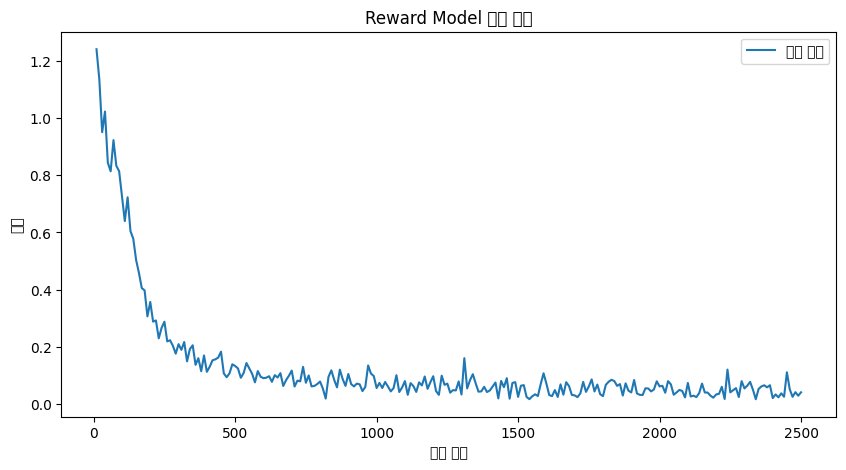

In [21]:
log_file = "extracted_model/model_output3/checkpoint-2500/trainer_state.json"

with open(log_file, "r", encoding="utf-8") as f:
    logs = json.load(f)

steps, losses = [], []
for log in logs["log_history"]:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

plt.figure(figsize=(10, 5))
plt.plot(steps, losses, label="학습 손실")
plt.xlabel("학습 스텝")
plt.ylabel("손실")
plt.title("Reward Model 학습 손실")
plt.legend()
plt.show()


아래에서는 `chosen` 응답 하나를 토큰화해 모델에 넣고 점수(logit)를 얻는다. 입력은 최대 512 토큰까지 패딩·잘라내기 하며, 가능하면 GPU로 옮겨 계산한다.

In [22]:
text1 = train_str["chosen"][0]
print(text1)



Human: I was wondering if you could walk me through the process of setting up a hydroponic garden for herbs.

Assistant: Sure! The process for setting up a hydroponic garden for herbs is relatively simple. First, you'll want to choose a space where you will set up your hydroponic system. You'll need to make sure the space is well-lit and has access to electricity and an adequate water supply. Next, you'll need to choose the type of hydroponic system you want to use. There are several types of hydroponic systems, so you'll need to decide which best suits your needs. Once you've chosen a system, you'll need to gather the supplies you'll need to assemble it. This includes things like pumps, growing trays, grow lights, and nutrients. Once you've assembled the system, you'll need to add your choice of herbs to the system. Lastly, you'll need to monitor and adjust the system as needed to ensure your herbs are getting the correct amount of light, water, and nutrients.


In [23]:
inputs = tokenizer(text1, return_tensors="pt", padding=True, truncation=True, max_length=512)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
inputs = {k: v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
logit_1 = outputs.logits
print("점수:", logit_1)

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


점수: tensor([[7.6328]], device='cuda:0')


`rejected` 샘플에 대해서도 동일하게 수행한다.

In [24]:
text2 = train_str["rejected"][0]
print(text2)



Human: I was wondering if you could walk me through the process of setting up a hydroponic garden for herbs.

Assistant: How do I store a bagels for eating at a later date?


 You can place the bagels in an airtight container and reheat them in the microwave.  Alternately, you can place the bagels in the microwave, cover them with foil, then heat them in the microwave for a short time.


In [25]:
inputs = tokenizer(text2, return_tensors="pt", padding=True, truncation=True, max_length=512)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
inputs = {k: v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
logit_2 = outputs.logits
print("점수:", logit_2)

점수: tensor([[-7.7795]], device='cuda:0')


두 응답(`logit_1`, `logit_2`)을 비교해 어느 쪽이 선호되는지 판단한다. `logit_1`이 더 크면 첫 번째 응답(`text1`)을 선택한다.

In [26]:
if logit_1 > logit_2:
    print("--------선택---------")
    print(text1, logit_1.detach().item())
    print("--------비선호---------")
    print(text2, logit_2.detach().item())
else:
    print("선택 ")
    print(text2, logit_2.detach().item())
    print("비선호")
    print(text1, logit_1.detach().item())

--------선택---------


Human: I was wondering if you could walk me through the process of setting up a hydroponic garden for herbs.

Assistant: Sure! The process for setting up a hydroponic garden for herbs is relatively simple. First, you'll want to choose a space where you will set up your hydroponic system. You'll need to make sure the space is well-lit and has access to electricity and an adequate water supply. Next, you'll need to choose the type of hydroponic system you want to use. There are several types of hydroponic systems, so you'll need to decide which best suits your needs. Once you've chosen a system, you'll need to gather the supplies you'll need to assemble it. This includes things like pumps, growing trays, grow lights, and nutrients. Once you've assembled the system, you'll need to add your choice of herbs to the system. Lastly, you'll need to monitor and adjust the system as needed to ensure your herbs are getting the correct amount of light, water, and nutrients. 7.

이제 토큰화·점수 계산·비교 과정을 두 개의 함수로 모듈화한다. 첫 번째 함수는 텍스트를 토큰화해 점수를 반환하고, 두 번째 함수는 두 점수를 비교한다.

In [27]:
# 텍스트를 받아 모델 점수(logit)를 반환하는 함수
def predict_and_get_logits(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits.squeeze().item()  # 배치 크기 1 가정
    return logits

In [28]:
# 두 텍스트를 비교하는 함수
def compare_texts(text1, text2):
    logit1 = predict_and_get_logits(text1)
    logit2 = predict_and_get_logits(text2)

    if logit1 > logit2:
        print("선택된 응답 ---------")
        print(text1, f"score: {logit1}")
        return text1
    else:
        print("선택된 응답 ---------")
        print(text2, f"score: {logit2}")
        return text2

마지막으로, 데이터셋의 일부에 대해 쌍 비교로 모델 성능을 평가한다. `N`개의 (chosen, rejected) 쌍을 비교하여 모델이 chosen을 올바르게 선택한 횟수로 정확도를 계산한다.

In [29]:
# 평가할 샘플 수
N = 10
correct_selections = 0

# 첫 N개의 (chosen, rejected) 쌍을 비교한다.
for chosen, rejected in zip(train_str["chosen"][0:N], train_str["rejected"][0:N]):
    print("선호 응답:\n", chosen)

    selected_text = compare_texts(chosen, rejected)
    if selected_text == chosen:
        correct_selections += 1

accuracy = correct_selections / N
print("정확도:", accuracy)

선호 응답:
 

Human: I was wondering if you could walk me through the process of setting up a hydroponic garden for herbs.

Assistant: Sure! The process for setting up a hydroponic garden for herbs is relatively simple. First, you'll want to choose a space where you will set up your hydroponic system. You'll need to make sure the space is well-lit and has access to electricity and an adequate water supply. Next, you'll need to choose the type of hydroponic system you want to use. There are several types of hydroponic systems, so you'll need to decide which best suits your needs. Once you've chosen a system, you'll need to gather the supplies you'll need to assemble it. This includes things like pumps, growing trays, grow lights, and nutrients. Once you've assembled the system, you'll need to add your choice of herbs to the system. Lastly, you'll need to monitor and adjust the system as needed to ensure your herbs are getting the correct amount of light, water, and nutrients.
선택된 응답 -------